In [76]:
import os
import re
import glob
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '../../src')
import utils

In [77]:
# ── Configure ──────────────────────────────────────────────────────────────────
log_dir     = '../../outputs/slurm_logs'
figures_dir = '../../figures/sensitivity_runtime'
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(figures_dir, exist_ok=True)

T_values    = [0, 1, 2, 3, 4]
nmax_values = [50, 100, 150, 200, 250, 300]

## Parse SLURM logs

For each `sens_T{T}_nmax{N}_*.out` file we extract:
- **Total elapsed** (seconds) from the line `Total elapsed: X.Xs`
- **Total MDP solves** from the line `Total MDP solves : N`

Jobs that are still running (no `Total elapsed` line) are recorded as `NaN`.

In [78]:
re_elapsed = re.compile(r'Total elapsed:\s*([\d.]+)s')
re_solves  = re.compile(r'Total MDP solves\s*:\s*(\d+)')
re_job     = re.compile(r'sens_T(\d+)_nmax(\d+)_')

# Initialize grids with NaN  (rows = T, cols = n_max)
T_idx    = {t: i for i, t in enumerate(T_values)}
nmax_idx = {n: j for j, n in enumerate(nmax_values)}

grid_elapsed = np.full((len(T_values), len(nmax_values)), np.nan)
grid_solves  = np.full((len(T_values), len(nmax_values)), np.nan)

log_files = sorted(glob.glob(os.path.join(log_dir, 'sens_T*_nmax*.out')))
print(f'Found {len(log_files)} log files')

parsed, missing = [], []

for path in log_files:
    fname = os.path.basename(path)
    m = re_job.search(fname)
    if not m:
        continue
    T, nmax = int(m.group(1)), int(m.group(2))
    if T not in T_idx or nmax not in nmax_idx:
        continue

    with open(path) as f:
        text = f.read()

    m_elapsed = re_elapsed.search(text)
    m_solves  = re_solves.search(text)

    i, j = T_idx[T], nmax_idx[nmax]

    if m_elapsed:
        grid_elapsed[i, j] = float(m_elapsed.group(1))
        parsed.append((T, nmax))
    else:
        missing.append((T, nmax))

    if m_solves:
        grid_solves[i, j] = int(m_solves.group(1))

print(f'  Completed : {len(parsed)}')
if missing:
    print(f'  Still running / missing : {missing}')

print()
print('Elapsed-time grid (rows=T, cols=n_max):')
print('n_max →  ', '  '.join(f'{n:>6}' for n in nmax_values))
for i, T in enumerate(T_values):
    row = '  '.join(f'{grid_elapsed[i,j]:>6.1f}' if not np.isnan(grid_elapsed[i,j]) else '   NaN' for j in range(len(nmax_values)))
    print(f'T={T}      {row}')

Found 30 log files
  Completed : 30

Elapsed-time grid (rows=T, cols=n_max):
n_max →       50     100     150     200     250     300
T=0         5.2     5.2     5.2     5.3     5.3     5.3
T=1         5.4     5.4     6.2     9.0    12.3    19.6
T=2         2.8     4.0    12.6    43.4   123.0   369.6
T=3         1.6    10.6    62.8   271.8   729.5  1771.0
T=4         6.5    39.3   239.4  1043.9  2402.1  5875.7


## Colourmap: elapsed time

Saved: ../../figures/sensitivity_runtime/runtime_elapsed.pdf


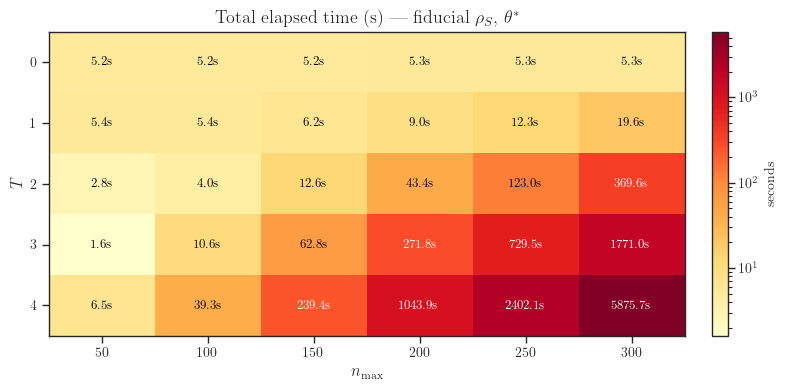

In [79]:
from matplotlib.colors import LogNorm

def _annotate(ax, data, fmt='{:.1f}', color_thresh=0.6, norm=None):
    """Overlay text annotations on each cell."""
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)
    span = vmax - vmin if vmax > vmin else 1.0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if np.isnan(v):
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=9, color='grey')
            else:
                if norm is not None:
                    brightness = norm(v)  # 0-1 in transformed space
                else:
                    brightness = (v - vmin) / span
                txt_color  = 'white' if brightness > color_thresh else 'black'
                ax.text(j, i, fmt.format(v), ha='center', va='center',
                        fontsize=9, color=txt_color, fontweight='bold')


fig, ax = plt.subplots(figsize=(8, 4))

# Mask NaN for colouring
masked = np.ma.masked_invalid(grid_elapsed)
cmap   = plt.cm.YlOrRd.copy()
cmap.set_bad(color='#dddddd')

log_norm_e = LogNorm(vmin=np.nanmin(grid_elapsed), vmax=np.nanmax(grid_elapsed))
im = ax.imshow(masked, aspect='auto', cmap=cmap, origin='upper', norm=log_norm_e)

_annotate(ax, grid_elapsed, fmt='{:.1f}s', norm=log_norm_e)

ax.set_xticks(range(len(nmax_values)))
ax.set_xticklabels(nmax_values)
ax.set_yticks(range(len(T_values)))
ax.set_yticklabels(T_values)
ax.set_xlabel(r'$n_{\max}$', fontsize=12)
ax.set_ylabel(r'$T$', fontsize=12)
ax.set_title('Total elapsed time (s)  —  fiducial $\\rho_S$, $\\theta^*$', fontsize=13)

cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('seconds', fontsize=10)

fig.tight_layout()
out = os.path.join(figures_dir, 'runtime_elapsed.pdf')
fig.savefig(out, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## Colourmap: number of MDP solves

Saved: ../../figures/sensitivity_runtime/runtime_mdp_solves.pdf


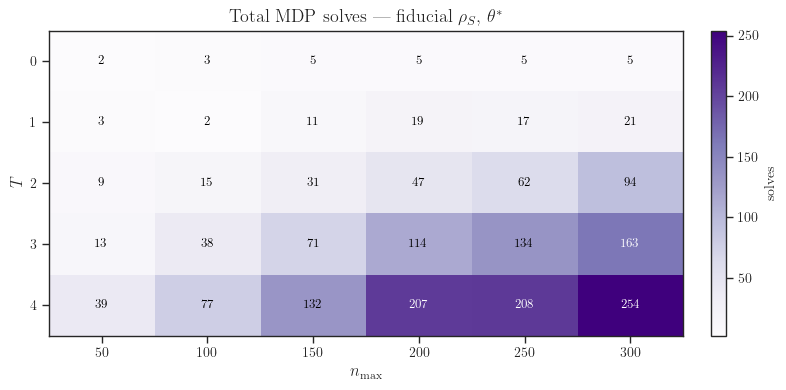

In [106]:
fig, ax = plt.subplots(figsize=(8, 4))

masked_s = np.ma.masked_invalid(grid_solves)
cmap_s   = plt.cm.Purples.copy()
cmap_s.set_bad(color='#dddddd')

im2 = ax.imshow(masked_s, aspect='auto', cmap=cmap_s, origin='upper')

_annotate(ax, grid_solves, fmt='{:.0f}')

ax.set_xticks(range(len(nmax_values)))
ax.set_xticklabels(nmax_values)
ax.set_yticks(range(len(T_values)))
ax.set_yticklabels(T_values)
ax.set_xlabel(r'$n_{\max}$', fontsize=12)
ax.set_ylabel(r'$T$', fontsize=12)
ax.set_title('Total MDP solves  —  fiducial $\\rho_S$, $\\theta^*$', fontsize=13)

cb2 = fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label('solves', fontsize=10)

fig.tight_layout()
out2 = os.path.join(figures_dir, 'runtime_mdp_solves.pdf')
fig.savefig(out2, bbox_inches='tight')
print(f'Saved: {out2}')
plt.show()

## Combined figure (side by side)

Saved: ../../figures/sensitivity_runtime/runtime_combined.pdf


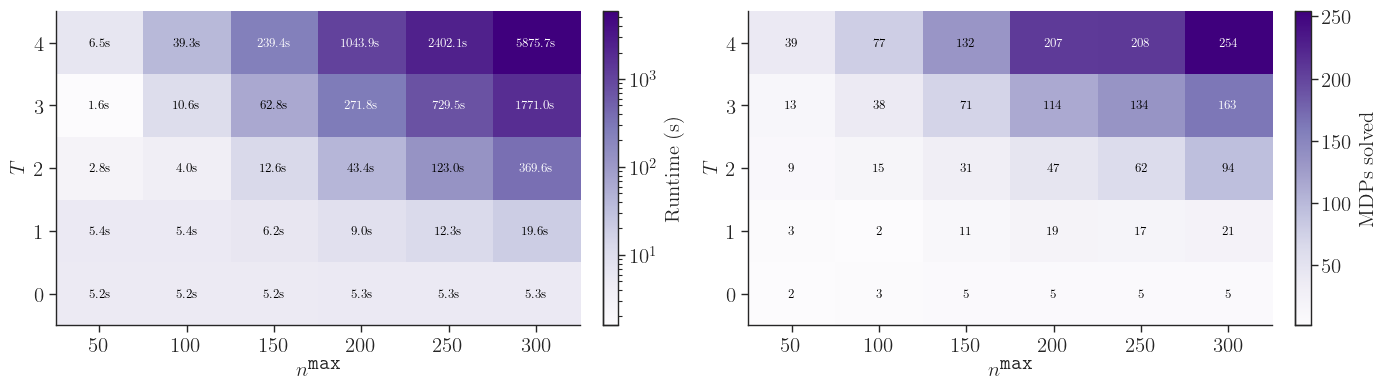

In [110]:
sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()
width_pt = 750

fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left: elapsed time (log colour scale) ---
ax = axes[0]
masked_e   = np.ma.masked_invalid(grid_elapsed)
cmap_e     = plt.cm.Purples.copy(); cmap_e.set_bad('#dddddd')
log_norm_e = LogNorm(vmin=np.nanmin(grid_elapsed), vmax=np.nanmax(grid_elapsed))
im_e = ax.imshow(masked_e, aspect='auto', cmap=cmap_e, origin='lower', norm=log_norm_e)
_annotate(ax, grid_elapsed, fmt='{:.1f}s', norm=log_norm_e)
ax.set_xticks(range(len(nmax_values))); ax.set_xticklabels(nmax_values, fontsize=15)
ax.set_yticks(range(len(T_values)));   ax.set_yticklabels(T_values, fontsize=15)
ax.set_xlabel(r'$n^{\texttt{max}}$', fontsize=15)
ax.set_ylabel(r'$T$', fontsize=15)
fig.colorbar(im_e, ax=ax, fraction=0.046, pad=0.04).set_label('Runtime (s)', fontsize=15)


# --- Right: MDP solves ---
ax = axes[1]
masked_s = np.ma.masked_invalid(grid_solves)
cmap_s   = plt.cm.Purples.copy()
cmap_s.set_bad('#dddddd')
im_s = ax.imshow(masked_s, aspect='auto', cmap=cmap_s, origin='lower')
_annotate(ax, grid_solves, fmt='{:.0f}')
ax.set_xticks(range(len(nmax_values))); ax.set_xticklabels(nmax_values, fontsize=15)
ax.set_yticks(range(len(T_values)));   ax.set_yticklabels(T_values, fontsize=15)
ax.set_xlabel(r'$n^{\texttt{max}}$', fontsize=15)
ax.set_ylabel(r'$T$', fontsize=15)
fig.colorbar(im_s, ax=ax, fraction=0.046, pad=0.04).set_label('MDPs solved', fontsize=15)
# Set colorbar tick size
for ax in axes:
    cbar = ax.images[0].colorbar
    cbar.ax.tick_params(labelsize=15)

fig.tight_layout()
sns.despine()

out3 = os.path.join(figures_dir, 'runtime_combined.pdf')
fig.savefig(out3, bbox_inches='tight')
print(f'Saved: {out3}')
plt.show()